# Streaming and exporting simulation products
Large dynamic calculations should not retain every map in accelerator memory. This notebook streams maps directly into finite-source photometry, saves only selected frames through a map observer, exports a compact light curve, and reconstructs a saved map with its physical grid. The numerical calculation uses CUDA/Triton when available.

The package returns ordinary typed objects containing Torch tensors and metadata. NumPy NPZ is a convenient dependency-free interchange format. FITS export is shown when Astropy is installed. The same observer pattern can instead write to HDF5, Zarr, a database, or an analysis pipeline.

In [1]:
from pathlib import Path
import json
import math
import platform
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device='cuda' if use_cuda else 'cpu',
    backend='triton' if use_cuda else 'auto',
    dtype=torch.float32,
    strict_backend=use_cuda,
    memory_fraction=0.80,
)
print('Platform:', platform.platform())
print('GPU:', capabilities.gpu_name)
print('Selected runtime:', mc.resolve_runtime(runtime_config))
output_directory = Path('microcaustics_tutorial_output')
output_directory.mkdir(exist_ok=True)


Platform: Windows-10-10.0.26200-SP0
GPU: NVIDIA GeForce RTX 5070 Ti
Selected runtime: ResolvedRuntime(device=device(type='cuda'), backend=<Backend.TRITON: 'triton'>, dtype=torch.float32, memory_fraction=0.8, strict_backend=True, torch_compile_mode=None, capabilities=RuntimeCapabilities(platform='Windows-10-10.0.26200-SP0', torch_version='2.12.1+cu130', cuda_available=True, cuda_version='13.0', mps_available=False, torch_compile_available=True, triton_importable=True, gpu_name='NVIDIA GeForce RTX 5070 Ti', total_device_memory_bytes=17094475776), fallback_reason=None)


In [2]:
distances = mc.LensingDistances.from_redshifts(0.0395, 1.695)
macro = mc.MacroLens(
    convergence=0.391, shear=0.391, shear_angle_deg=141.73,
)
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
trajectory = mc.LinearTrajectory(velocity_uas_per_day=(2.0e-4, -1.0e-4))
source_model = mc.GaussianModel.from_angular(
    distances,
    sigma_uas=(0.20, 0.30),
    wavelengths_angstrom=(4800.0, 7500.0),
    band_names=('blue', 'red'),
    grid=mc.SourceGridConfig(
        shape=1024, enclosed_flux_fraction=0.999, margin=1.05,
    ),
)
source = source_model.pixelate(distances, runtime=runtime_config)
source_grid = source_model.recommended_grid(distances).covering_trajectory(
    trajectory, map_times, margin=1.05,
)
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.IsotropicKinematics(dispersion_km_s=170.0),
)
method = mc.production_ipm_config(dynamic=True, rays=10_000_000 if use_cuda else 262_144)
schedule = mc.production_dynamic_config()
system = mc.MicrolensingSystem.from_redshifts(
    lens_redshift=lens_redshift,
    source_redshift=source_redshift,
    H0=70.0,
    Om0=0.3,
    macro=macro,
    source=source,
    source_grid=source_grid,
    stellar_population=population,
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed=1001,
    runtime=runtime_config,
)


## Save selected maps while streaming a light curve
The observer receives each real frame after computation. It immediately copies only the first, middle, and final epochs to CPU storage. All other maps are consumed by photometry and released. Metadata are stored as JSON text with a string fallback for non-JSON-native values.

In [3]:
saved_paths = []
selected_indices = {0, len(map_times) // 2, len(map_times) - 1}

def save_selected_map(index, magnification_map):
    if index not in selected_indices:
        return
    path = output_directory / f'map_{index:03d}.npz'
    np.savez_compressed(
        path,
        values=magnification_map.numpy(),
        shape=np.asarray(magnification_map.grid.shape, dtype=np.int64),
        field_of_view_uas=np.asarray(magnification_map.grid.field_of_view_uas, dtype=np.float64),
        center_uas=np.asarray(magnification_map.grid.center_uas, dtype=np.float64),
        time_days=np.asarray(magnification_map.time_days, dtype=np.float64),
        method=np.asarray(magnification_map.method),
        metadata_json=np.asarray(json.dumps(dict(magnification_map.metadata), default=str)),
    )
    saved_paths.append(path)

curve = system.multirate_light_curve(
    map_times, flux_times,
    method=method,
    trajectory=trajectory,
    schedule=schedule,
    map_observer=save_selected_map,
)
np.savez_compressed(
    output_directory / 'light_curve.npz',
    times_days=curve.times_days.detach().cpu().numpy(),
    flux=curve.flux.detach().cpu().numpy(),
    unlensed_flux=curve.unlensed_flux.detach().cpu().numpy(),
    band_names=np.asarray(curve.band_names),
    metadata_json=np.asarray(json.dumps(dict(curve.metadata), default=str)),
)
print('Saved maps:', [str(path) for path in saved_paths])
print('Light-curve shape:', tuple(curve.flux.shape))
print('Delivered runtime [s]:', curve.timing.delivered_seconds)
print('Requested base-cell budget:', f'{method.rays:,}')


Saved maps: ['microcaustics_tutorial_output\\map_000.npz', 'microcaustics_tutorial_output\\map_073.npz', 'microcaustics_tutorial_output\\map_146.npz']
Light-curve shape: (3651, 2)
Delivered runtime [s]: 5.898687599983532
Requested base-cell budget: 10,000,000


## Reconstruct and inspect a saved map
Reconstruction uses the saved field of view, center, shape, epoch, and method. This keeps map coordinates explicit rather than treating the array as an unregistered image.

Stored requested base cells: 10000000
Stored actual base cells: 9998244


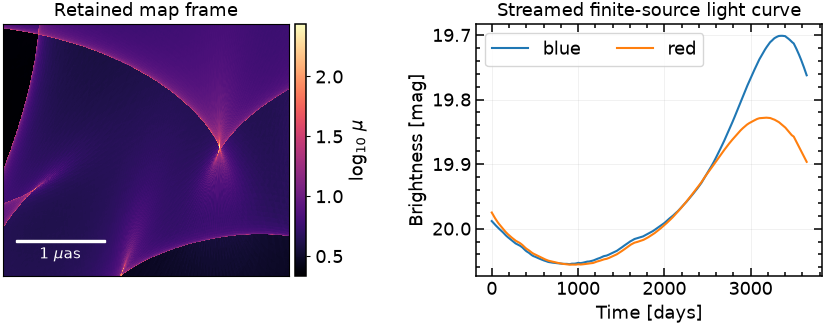

In [4]:
with np.load(saved_paths[0], allow_pickle=False) as stored:
    loaded_grid = mc.PlaneGrid(
        tuple(int(value) for value in stored['shape']),
        tuple(float(value) for value in stored['field_of_view_uas']),
        tuple(float(value) for value in stored['center_uas']),
    )
    loaded_map = mc.MagnificationMap(
        torch.from_numpy(stored['values'].copy()),
        loaded_grid,
        time_days=float(stored['time_days']),
        method=str(stored['method']),
        metadata=json.loads(str(stored['metadata_json'])),
    )

figure, axes = plt.subplots(1, 2, figsize=(8.8, 3.6))
mcp.plot_magnification_map(loaded_map, ax=axes[0], scale_bar_uas=1.0, show_axes=False)
zero_points = {name: float(mc.zero_point_flux_for_magnitude(torch.median(curve.flux[:, index]), 20.0)) for index, name in enumerate(curve.band_names)}
mcp.plot_light_curve(curve, ax=axes[1], magnitude=True, zero_point_flux=zero_points)
axes[0].set_title('Retained map frame')
axes[1].set_title('Streamed finite-source light curve')
figure.tight_layout()
figure.savefig(output_directory / 'streamed_map_and_light_curve.png', dpi=220, bbox_inches='tight', facecolor='white')
print('Stored requested base cells:', loaded_map.metadata.get('requested_base_cells'))
print('Stored actual base cells:', loaded_map.metadata.get('actual_base_cells'))
assert int(loaded_map.metadata['requested_base_cells']) == int(method.rays)
assert abs(int(loaded_map.metadata['actual_base_cells']) - int(method.rays)) / int(method.rays) < 1.0e-3


## Optional FITS export
FITS is useful for astronomy tools and preserves physical registration in standard header keywords. Install the `science` extra to run this cell.

In [5]:
try:
    from astropy.io import fits
except ImportError:
    print('Install microcaustics[science] for FITS export.')
else:
    header = fits.Header()
    header['BUNIT'] = 'magnification'
    header['TIME'] = loaded_map.time_days
    header['CDELT1'] = loaded_grid.pixel_scale_uas[1]
    header['CDELT2'] = loaded_grid.pixel_scale_uas[0]
    header['CRVAL1'] = loaded_grid.center_uas[1]
    header['CRVAL2'] = loaded_grid.center_uas[0]
    fits.writeto(
        output_directory / 'map_000.fits', loaded_map.numpy(), header,
        overwrite=True,
    )
    print('Wrote', output_directory / 'map_000.fits')


Wrote microcaustics_tutorial_output\map_000.fits


For very long calculations, keep the observer lightweight and write each selected frame immediately. Use one file per frame or a chunked format such as Zarr/HDF5, record the full numerical configuration alongside the data, and verify available storage before retaining complete map sequences. Light-curve-only runs normally need no map files.